HEALTHCARE AI — READMISSION PREDICTION SYSTEM

Total Patients: 300
Readmitted: 156 (52.0%)
Not Readmitted: 144

--- Stats by Department ---
            patients  readmission_rate  avg_days
department                                      
Cardiology        86              0.50     10.43
Diabetes          62              0.50     10.35
Neurology         76              0.49      9.93
Oncology          76              0.59      9.91

--- High Risk Patients (age>65, BP>155, diabetes) ---
High risk patients: 15
Readmission rate in high risk: 100.0%

--- ML Model Performance ---
Accuracy: 90.0%
                precision    recall  f1-score   support

Not Readmitted       0.96      0.83      0.89        30
    Readmitted       0.85      0.97      0.91        30

      accuracy                           0.90        60
     macro avg       0.91      0.90      0.90        60
  weighted avg       0.91      0.90      0.90        60


--- Key Predictors ---
               feature  importance
2     

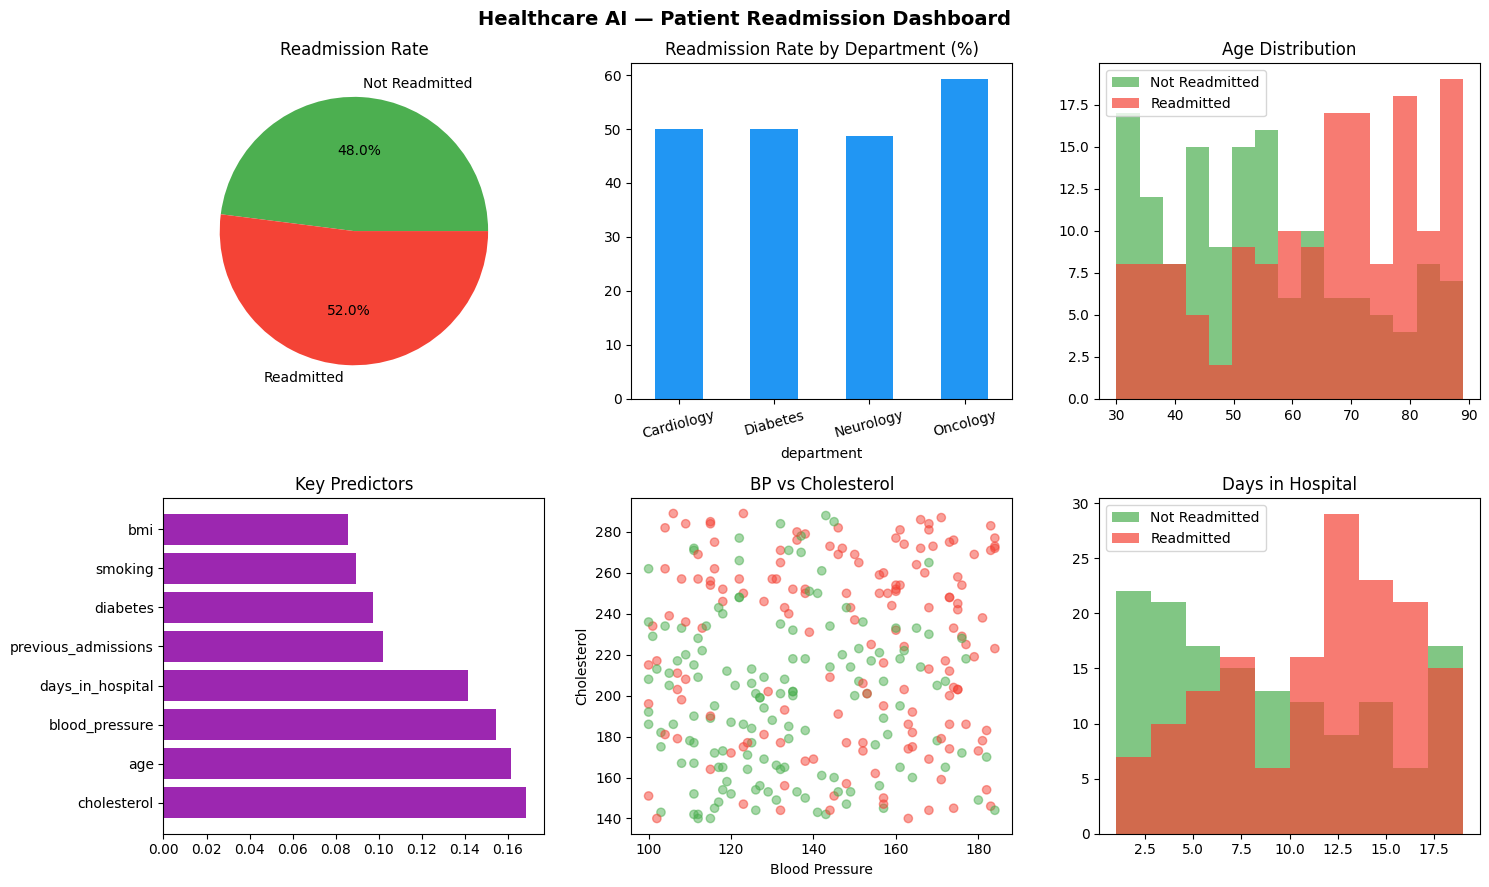


=== Files saved: healthcare_ai_dashboard.png + healthcare_ai_report.xlsx ===
=== Model Accuracy: 90.0% ===


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ============================================
# HEALTHCARE AI — PATIENT READMISSION SYSTEM
# ============================================

np.random.seed(42)
n = 300

df = pd.DataFrame({
    'patient_id': range(1, n+1),
    'age': np.random.randint(30, 90, n),
    'gender': np.random.choice(['Male', 'Female'], n),
    'blood_pressure': np.random.randint(100, 185, n),
    'cholesterol': np.random.randint(140, 290, n),
    'bmi': np.round(np.random.uniform(18, 40, n), 1),
    'days_in_hospital': np.random.randint(1, 20, n),
    'diabetes': np.random.choice([0, 1], n, p=[0.65, 0.35]),
    'smoking': np.random.choice([0, 1], n, p=[0.70, 0.30]),
    'previous_admissions': np.random.randint(0, 5, n),
    'department': np.random.choice(
        ['Cardiology', 'Diabetes', 'Neurology', 'Oncology'], n)
})

# Readmission logic
df['readmitted'] = (
    (df['age'] > 65).astype(int) +
    (df['blood_pressure'] > 155).astype(int) +
    (df['cholesterol'] > 240).astype(int) +
    (df['days_in_hospital'] > 10).astype(int) +
    df['diabetes'] +
    df['smoking'] +
    (df['previous_admissions'] > 2).astype(int)
)
df['readmitted'] = (df['readmitted'] >= 3).astype(int)

# ============================================
# EXPLORATORY ANALYSIS
# ============================================

print("=" * 50)
print("HEALTHCARE AI — READMISSION PREDICTION SYSTEM")
print("=" * 50)

print(f"\nTotal Patients: {n}")
print(f"Readmitted: {df['readmitted'].sum()} ({df['readmitted'].mean()*100:.1f}%)")
print(f"Not Readmitted: {n - df['readmitted'].sum()}")

print("\n--- Stats by Department ---")
dept_stats = df.groupby('department').agg(
    patients=('patient_id', 'count'),
    readmission_rate=('readmitted', 'mean'),
    avg_days=('days_in_hospital', 'mean')
).round(2)
print(dept_stats)

print("\n--- High Risk Patients (age>65, BP>155, diabetes) ---")
high_risk = df[
    (df['age'] > 65) &
    (df['blood_pressure'] > 155) &
    (df['diabetes'] == 1)
]
print(f"High risk patients: {len(high_risk)}")
print(f"Readmission rate in high risk: {high_risk['readmitted'].mean()*100:.1f}%")

# ============================================
# MACHINE LEARNING
# ============================================

features = ['age', 'blood_pressure', 'cholesterol', 'bmi',
            'days_in_hospital', 'diabetes', 'smoking', 'previous_admissions']

X = df[features]
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- ML Model Performance ---")
print(f"Accuracy: {accuracy*100:.1f}%")
print(classification_report(y_test, y_pred,
      target_names=['Not Readmitted', 'Readmitted']))

# Feature importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Key Predictors ---")
print(importance_df)

# ============================================
# DASHBOARD
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Healthcare AI — Patient Readmission Dashboard',
             fontsize=14, fontweight='bold')

# 1. Readmission rate
labels = ['Not Readmitted', 'Readmitted']
sizes = [n - df['readmitted'].sum(), df['readmitted'].sum()]
axes[0,0].pie(sizes, labels=labels, autopct='%1.1f%%',
              colors=['#4CAF50', '#F44336'])
axes[0,0].set_title('Readmission Rate')

# 2. By department
dept_read = df.groupby('department')['readmitted'].mean() * 100
dept_read.plot(kind='bar', ax=axes[0,1], color='#2196F3')
axes[0,1].set_title('Readmission Rate by Department (%)')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Age distribution
axes[0,2].hist(df[df['readmitted']==0]['age'],
               alpha=0.7, label='Not Readmitted', color='#4CAF50', bins=15)
axes[0,2].hist(df[df['readmitted']==1]['age'],
               alpha=0.7, label='Readmitted', color='#F44336', bins=15)
axes[0,2].set_title('Age Distribution')
axes[0,2].legend()

# 4. Feature importance
axes[1,0].barh(importance_df['feature'],
               importance_df['importance'], color='#9C27B0')
axes[1,0].set_title('Key Predictors')

# 5. BP vs Cholesterol
colors = df['readmitted'].map({0: '#4CAF50', 1: '#F44336'})
axes[1,1].scatter(df['blood_pressure'], df['cholesterol'],
                  c=colors, alpha=0.5)
axes[1,1].set_title('BP vs Cholesterol')
axes[1,1].set_xlabel('Blood Pressure')
axes[1,1].set_ylabel('Cholesterol')

# 6. Days in hospital
axes[1,2].hist(df[df['readmitted']==0]['days_in_hospital'],
               alpha=0.7, label='Not Readmitted', color='#4CAF50', bins=10)
axes[1,2].hist(df[df['readmitted']==1]['days_in_hospital'],
               alpha=0.7, label='Readmitted', color='#F44336', bins=10)
axes[1,2].set_title('Days in Hospital')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('healthcare_ai_dashboard.png', dpi=150)
plt.show()

# ============================================
# EXPORT
# ============================================

df.to_excel('healthcare_ai_report.xlsx', index=False)
print("\n=== Files saved: healthcare_ai_dashboard.png + healthcare_ai_report.xlsx ===")
print(f"=== Model Accuracy: {accuracy*100:.1f}% ===")